# 04 - Allen-Cahn Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t = \varepsilon^2 u_{xx} + u - u^3$, $\varepsilon = 0.01$

**IC:** $u(x,0) = x^2 \cos(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 128, 128, 128, 128, 128, 1]` | **Epochs:** 10000

**Note:** Allen-Cahn is the hardest test. Stiff PDE with sharp interface.
Vanilla PINN is known to fail here. This is AC-PINN's strongest showcase.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    AllenCahnFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'allen_cahn'
LAYERS     = [2, 128, 128, 128, 128, 128, 1]
EPOCHS     = 10000
PDE_PARAMS = {'epsilon': 0.01}
RESULTS    = '../results/allen_cahn/'
FIGURES    = '../figures/allen_cahn/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

AllenCahnFDM solved in 1.5852s


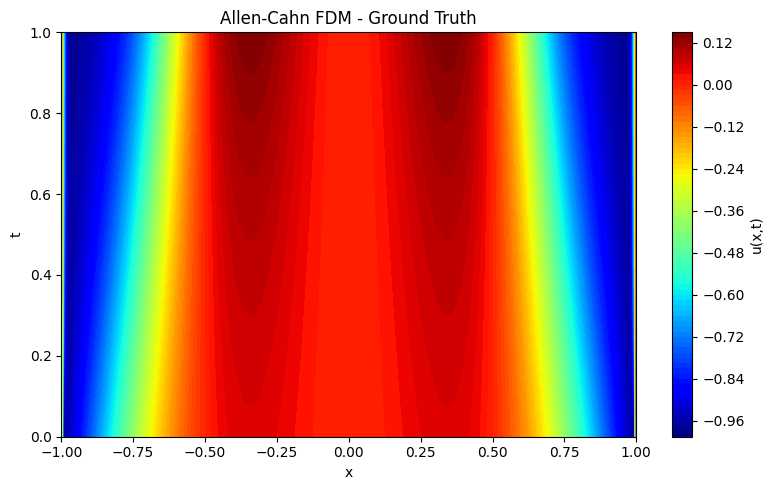

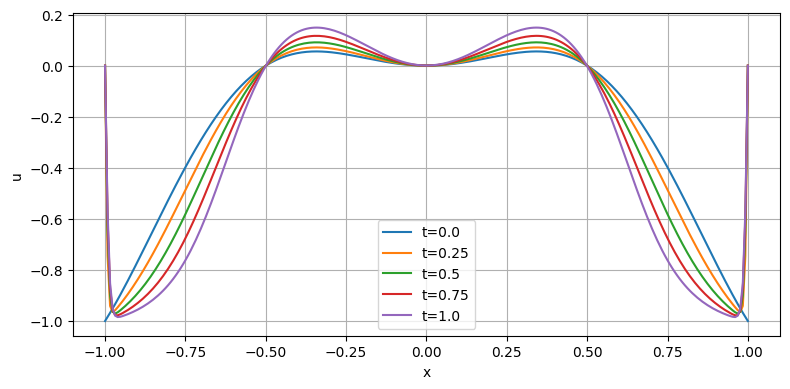

In [2]:
fdm = AllenCahnFDM(nx=256, nt=5000, epsilon=0.01)
fdm.solve()
fdm.plot_solution(title='Allen-Cahn FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
# Allen-Cahn needs more collocation points due to stiffness
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=10000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=3000,  noise_eps=0.1)
print('Data ready')

Data ready


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Allen-Cahn | Vanilla Clean | Epoch     0/10000] Total: 0.250139 | IC: 0.133730 | BC: 0.038592 | PDE: 0.007782


[Allen-Cahn | Vanilla Clean | Epoch  1000/10000] Total: 0.122200 | IC: 0.116095 | BC: 0.003503 | PDE: 0.000260


[Allen-Cahn | Vanilla Clean | Epoch  2000/10000] Total: 0.122029 | IC: 0.115973 | BC: 0.003392 | PDE: 0.000266


[Allen-Cahn | Vanilla Clean | Epoch  3000/10000] Total: 0.124568 | IC: 0.121356 | BC: 0.002104 | PDE: 0.000111


...

[Allen-Cahn | Vanilla Clean | Epoch  6000/10000] Total: 0.072993 | IC: 0.068282 | BC: 0.002585 | PDE: 0.000213


[Allen-Cahn | Vanilla Clean | Epoch  7000/10000] Total: 0.061615 | IC: 0.056719 | BC: 0.002073 | PDE: 0.000282


[Allen-Cahn | Vanilla Clean | Epoch  8000/10000] Total: 0.024273 | IC: 0.021385 | BC: 0.000786 | PDE: 0.000210


[Allen-Cahn | Vanilla Clean | Epoch  9000/10000] Total: 0.017059 | IC: 0.015046 | BC: 0.000644 | PDE: 0.000137



Training complete in 253.77s


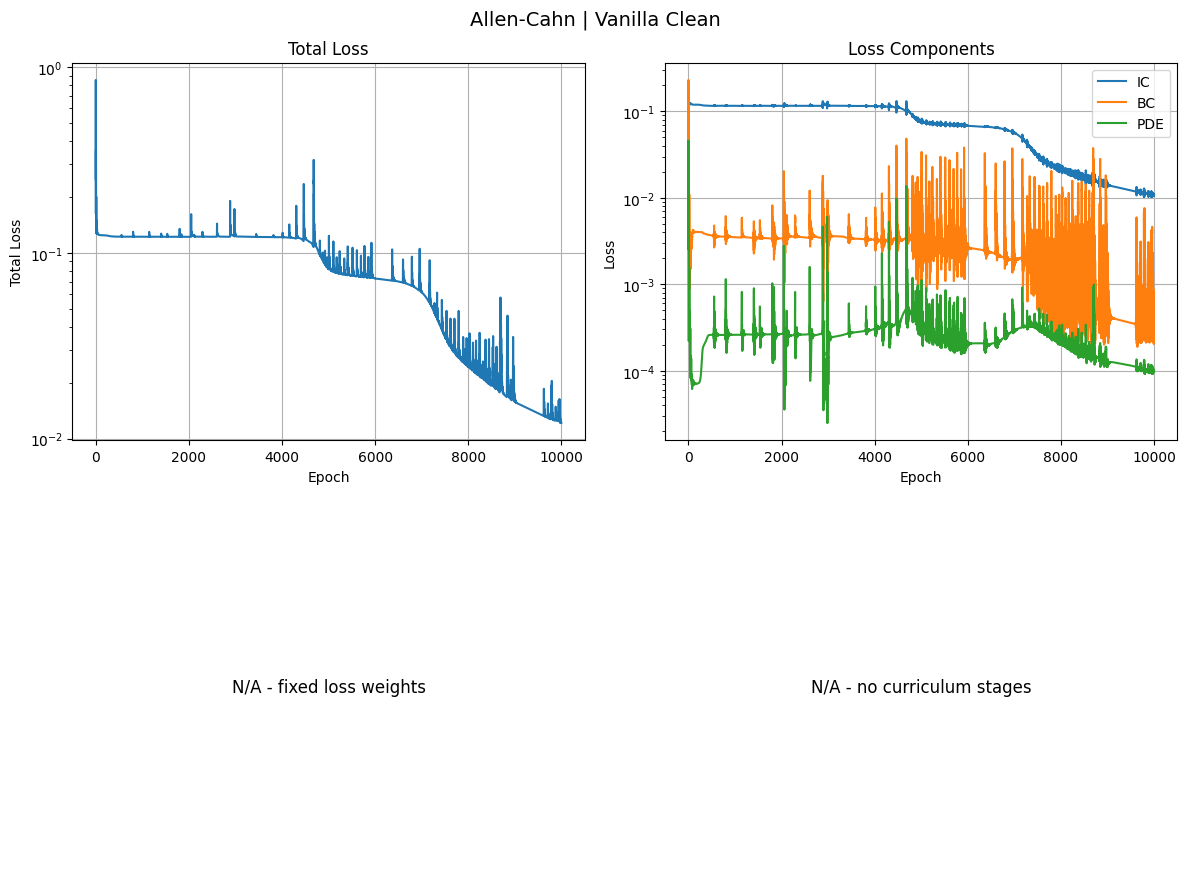

Saved: ../figures/allen_cahn/vanilla_clean_training.png
Saved: ../figures/allen_cahn/vanilla_clean_training.csv


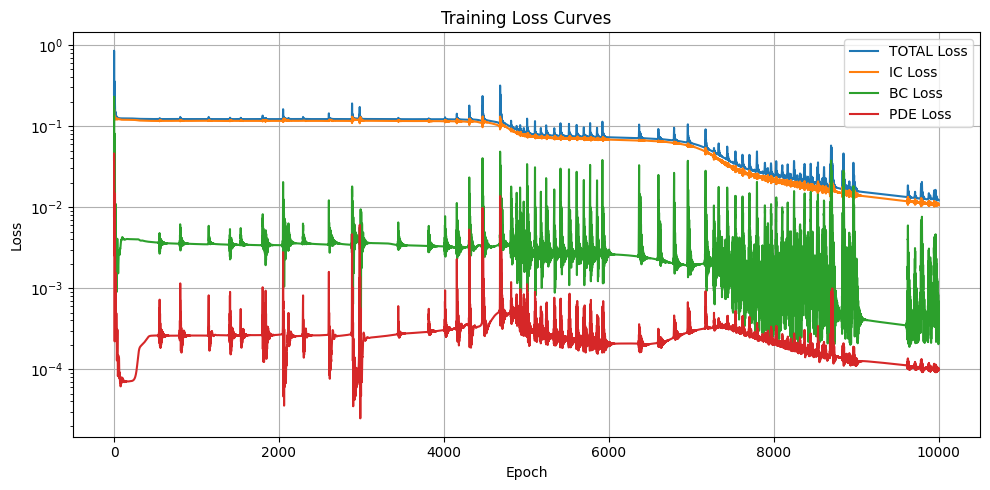

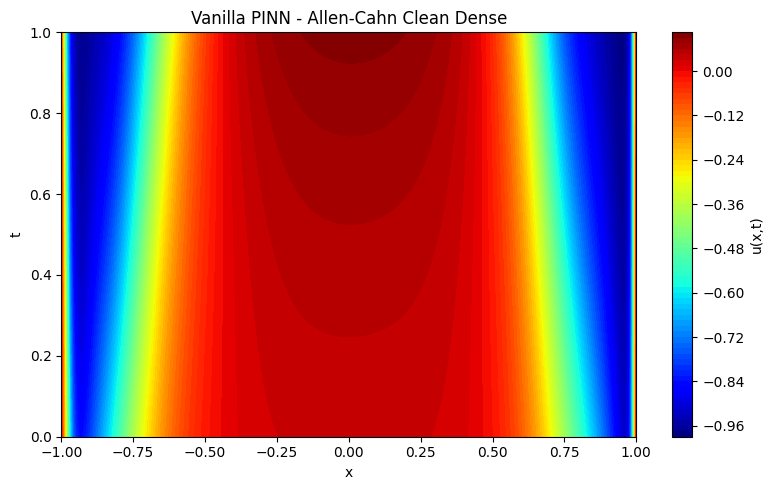

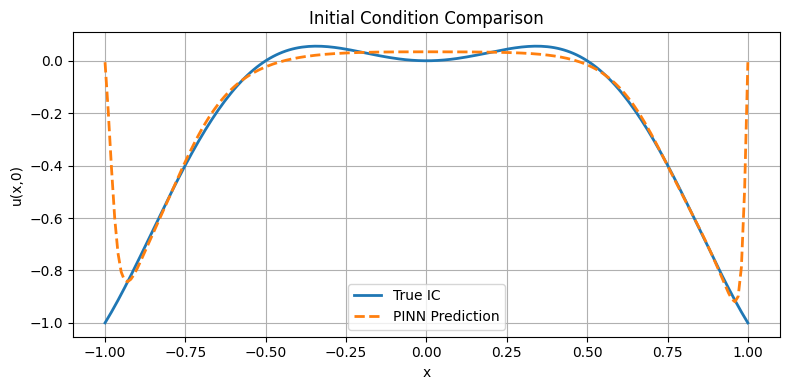

Saved: ../results/allen_cahn/vanilla_clean_history.npy


In [4]:
# Higher lambda_pde for stiff PDE
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Allen-Cahn | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Allen-Cahn Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse
⚠️ Vanilla PINN typically fails here on Allen-Cahn.

[Allen-Cahn | Vanilla Noisy | Epoch     0/10000] Total: 0.625396 | IC: 0.141018 | BC: 0.192975 | PDE: 0.029140


[Allen-Cahn | Vanilla Noisy | Epoch  1000/10000] Total: 0.182252 | IC: 0.123337 | BC: 0.028858 | PDE: 0.003006


[Allen-Cahn | Vanilla Noisy | Epoch  2000/10000] Total: 0.152483 | IC: 0.130373 | BC: 0.017348 | PDE: 0.000476


[Allen-Cahn | Vanilla Noisy | Epoch  3000/10000] Total: 0.149757 | IC: 0.128109 | BC: 0.016868 | PDE: 0.000478


[Allen-Cahn | Vanilla Noisy | Epoch  4000/10000] Total: 0.095590 | IC: 0.070515 | BC: 0.019324 | PDE: 0.000575


...

[Allen-Cahn | Vanilla Noisy | Epoch  6000/10000] Total: 0.061120 | IC: 0.046913 | BC: 0.011394 | PDE: 0.000281


[Allen-Cahn | Vanilla Noisy | Epoch  7000/10000] Total: 0.057499 | IC: 0.044836 | BC: 0.010919 | PDE: 0.000174


[Allen-Cahn | Vanilla Noisy | Epoch  8000/10000] Total: 0.055554 | IC: 0.042798 | BC: 0.011010 | PDE: 0.000175


[Allen-Cahn | Vanilla Noisy | Epoch  9000/10000] Total: 0.030743 | IC: 0.015307 | BC: 0.010725 | PDE: 0.000471



Training complete in 134.62s


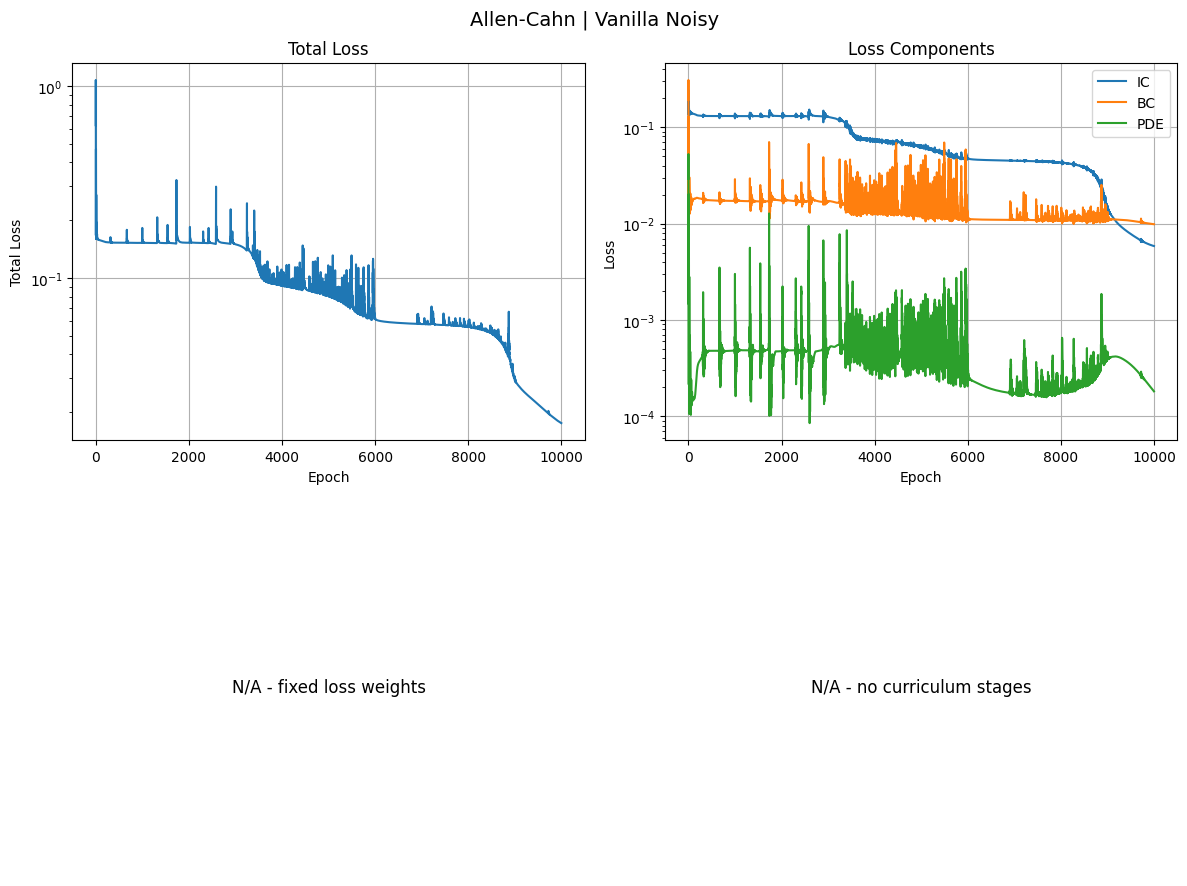

Saved: ../figures/allen_cahn/vanilla_noisy_training.png
Saved: ../figures/allen_cahn/vanilla_noisy_training.csv


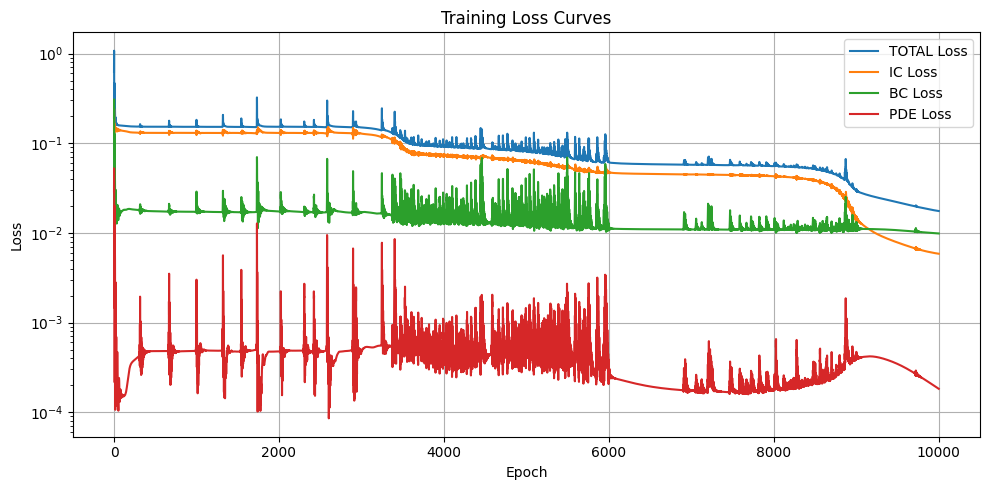

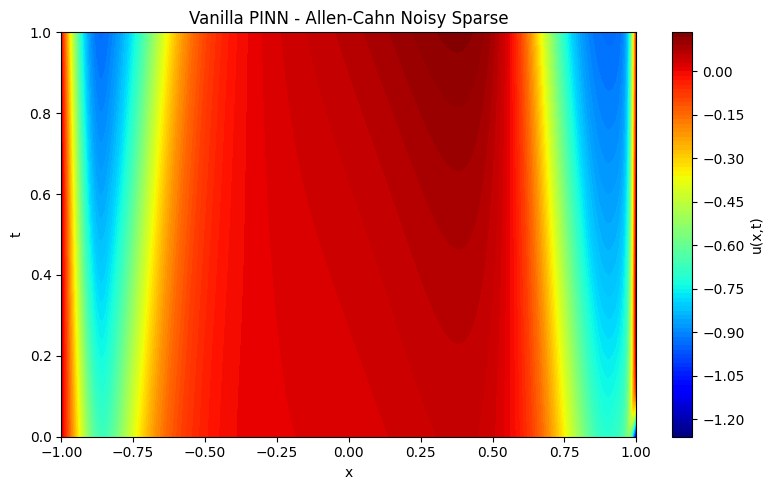

Saved: ../results/allen_cahn/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Allen-Cahn | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Allen-Cahn Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Allen-Cahn | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 0.134209 | IC: 0.130012 | BC: 0.003466 | PDE: 0.000146 | lam=(1.00,1.00,5.00)


[Allen-Cahn | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.009955 | IC: 0.000988 | BC: 0.003688 | PDE: 0.000006 | lam=(2.00,2.15,10.00)


[Allen-Cahn | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.001997 | IC: 0.000308 | BC: 0.000612 | PDE: 0.000001 | lam=(2.05,2.21,10.00)


[Allen-Cahn | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.008841 | IC: 0.005619 | BC: 0.000090 | PDE: 0.000015 | lam=(1.47,4.69,9.28)


[Allen-Cahn | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.000215 | IC: 0.000114 | BC: 0.000008 | PDE: 0.000000 | lam=(1.14,10.00,10.00)


...

[Allen-Cahn | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.000066 | IC: 0.000022 | BC: 0.000023 | PDE: 0.000001 | lam=(1.41,1.53,0.10)


[Allen-Cahn | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000035 | IC: 0.000011 | BC: 0.000012 | PDE: 0.000000 | lam=(1.40,1.58,0.10)


[Allen-Cahn | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.759720 | IC: 0.029336 | BC: 0.022416 | PDE: 0.293279 | lam=(0.26,0.19,2.55)


[Allen-Cahn | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.379571 | IC: 0.126685 | BC: 0.000056 | PDE: 0.000112 | lam=(3.00,0.10,0.10)



AC-PINN training complete in 272.09s


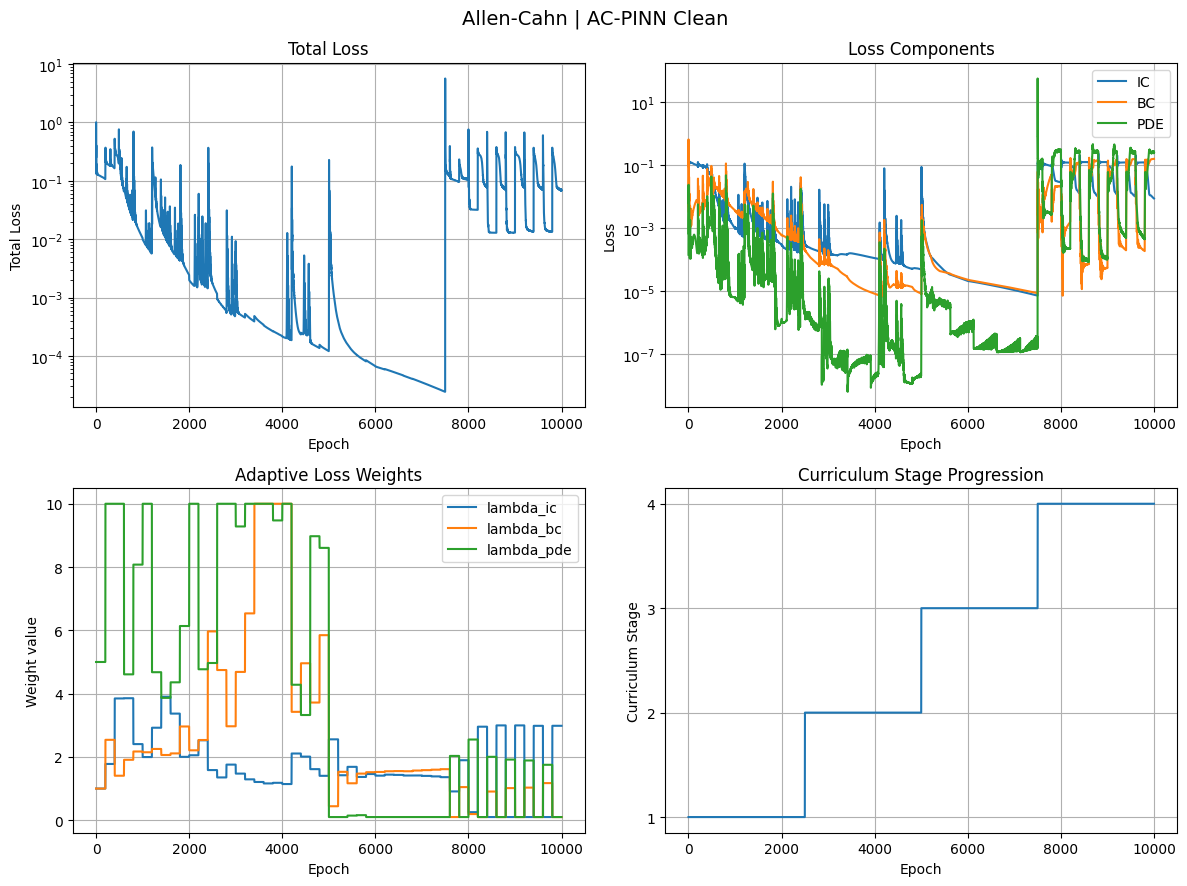

Saved: ../figures/allen_cahn/acpinn_clean_training.png
Saved: ../figures/allen_cahn/acpinn_clean_training.csv


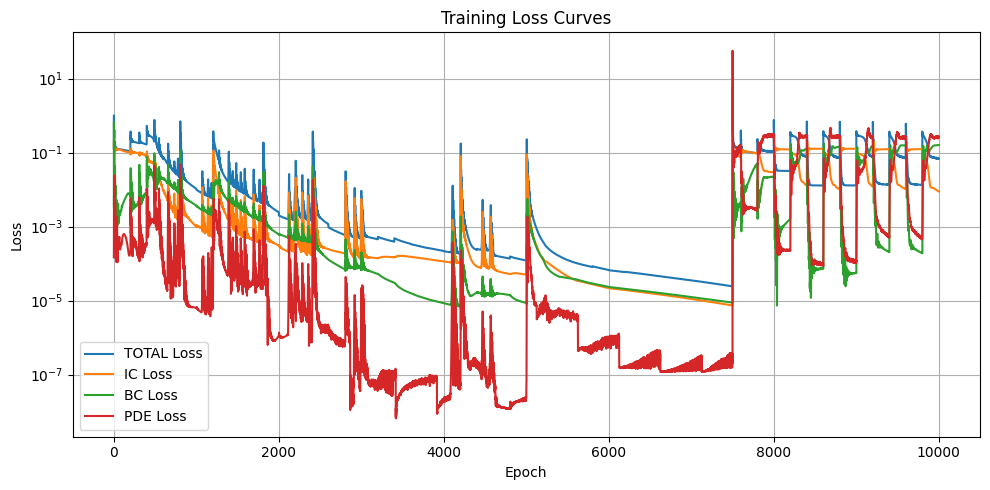

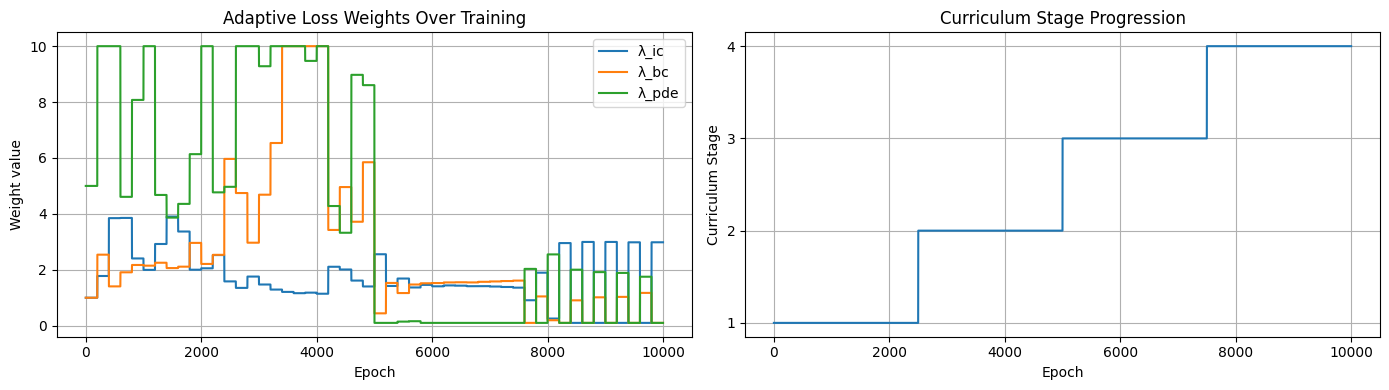

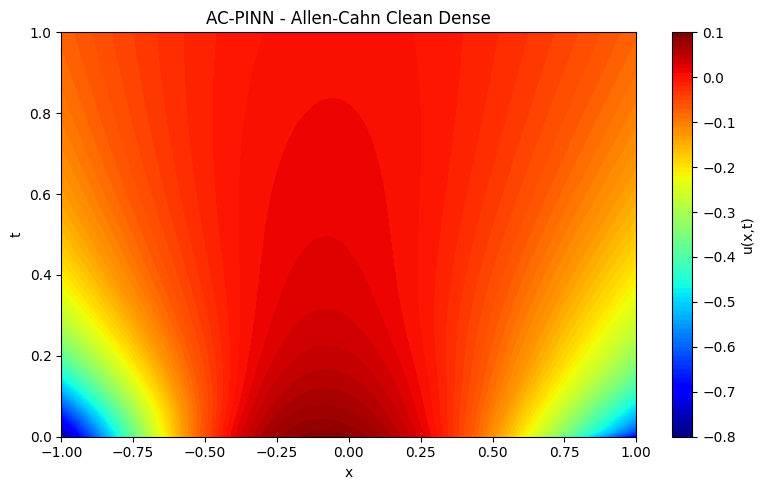

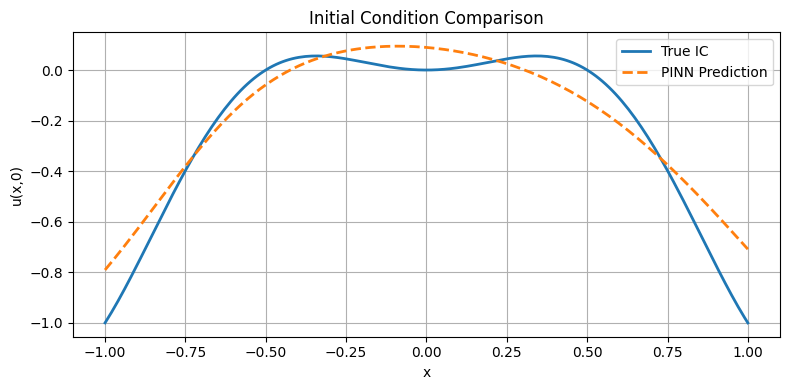

Saved: ../results/allen_cahn/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Allen-Cahn | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Allen-Cahn Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse
This is where AC-PINN should demonstrate its biggest advantage.

[Allen-Cahn | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.164362 | IC: 0.140810 | BC: 0.021678 | PDE: 0.000375 | lam=(1.00,1.00,5.00)


[Allen-Cahn | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.105526 | IC: 0.042435 | BC: 0.006998 | PDE: 0.000505 | lam=(1.25,6.76,10.00)


[Allen-Cahn | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.039865 | IC: 0.004674 | BC: 0.004386 | PDE: 0.001181 | lam=(5.90,1.97,3.10)


[Allen-Cahn | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.015377 | IC: 0.002018 | BC: 0.003059 | PDE: 0.000022 | lam=(3.35,2.80,2.91)


[Allen-Cahn | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.032723 | IC: 0.001983 | BC: 0.003029 | PDE: 0.000011 | lam=(10.00,4.25,1.42)


...

[Allen-Cahn | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.007350 | IC: 0.002085 | BC: 0.003057 | PDE: 0.000587 | lam=(1.09,1.60,0.31)


[Allen-Cahn | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.007351 | IC: 0.002029 | BC: 0.003039 | PDE: 0.000473 | lam=(1.10,1.65,0.26)


[Allen-Cahn | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.809379 | IC: 0.014152 | BC: 0.016233 | PDE: 0.295927 | lam=(0.13,0.15,2.72)


[Allen-Cahn | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.420191 | IC: 0.150171 | BC: 0.011764 | PDE: 0.000063 | lam=(2.78,0.22,0.10)



AC-PINN training complete in 151.21s


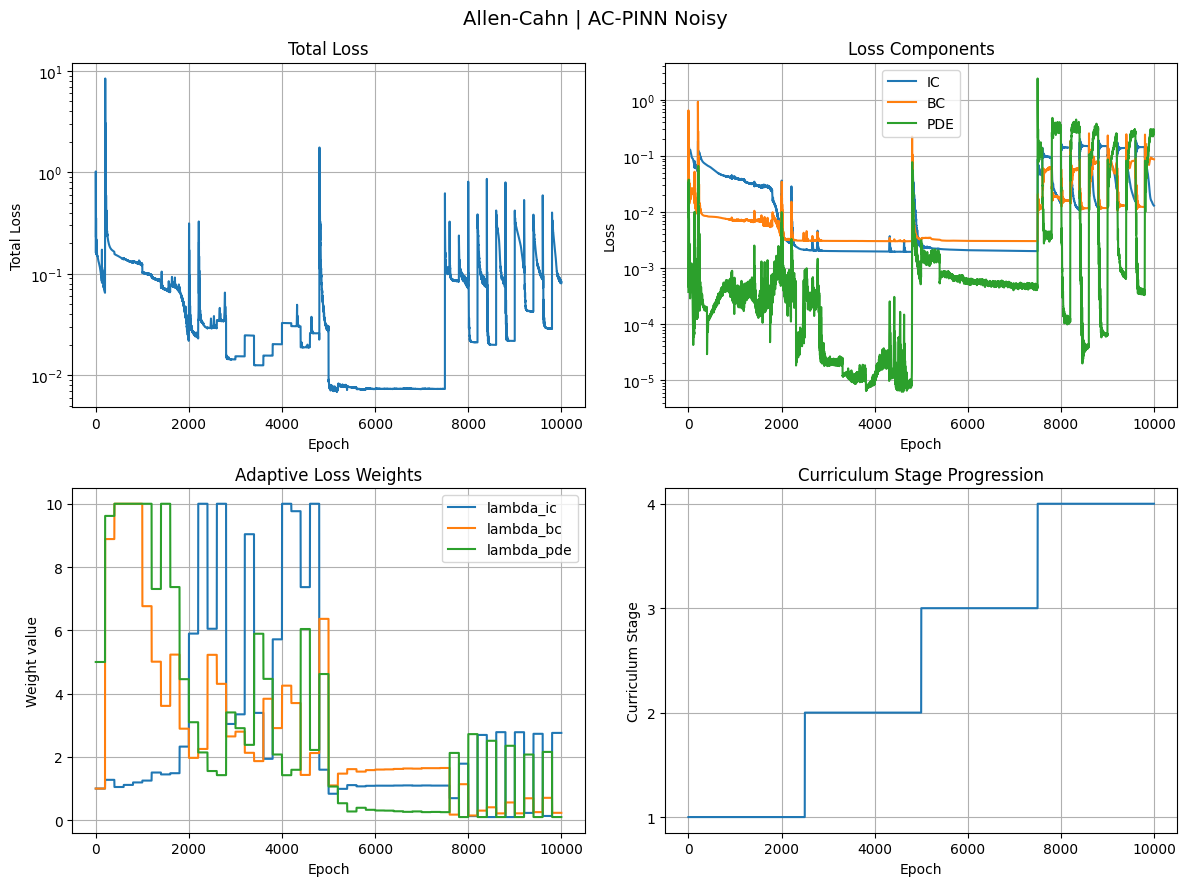

Saved: ../figures/allen_cahn/acpinn_noisy_training.png
Saved: ../figures/allen_cahn/acpinn_noisy_training.csv


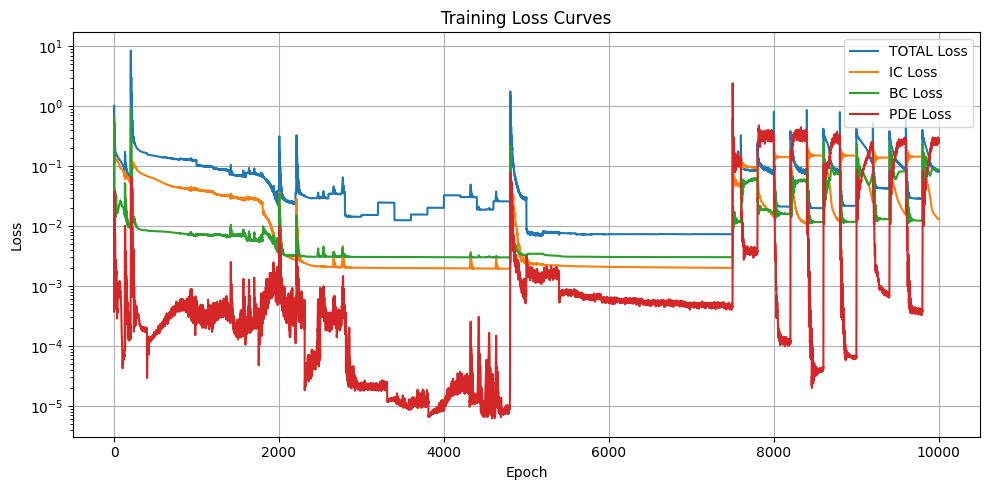

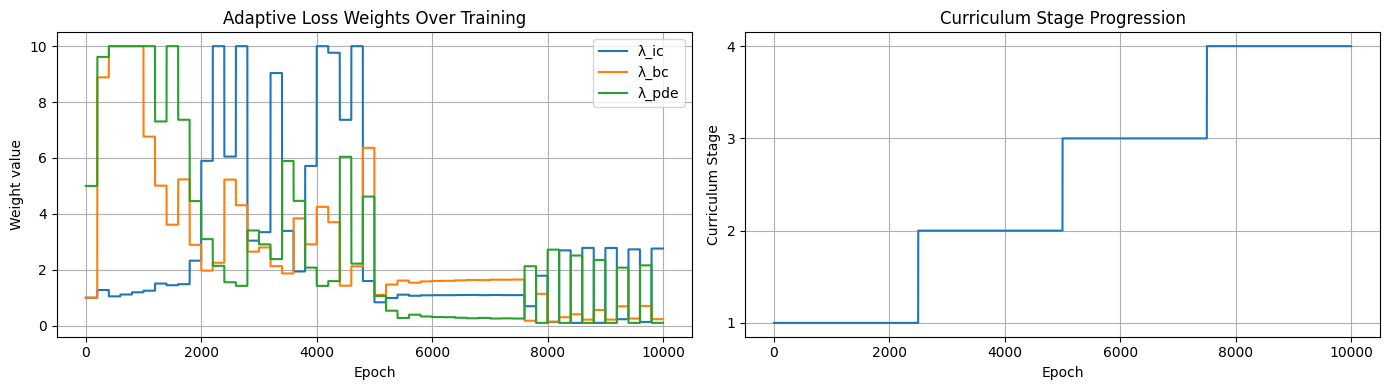

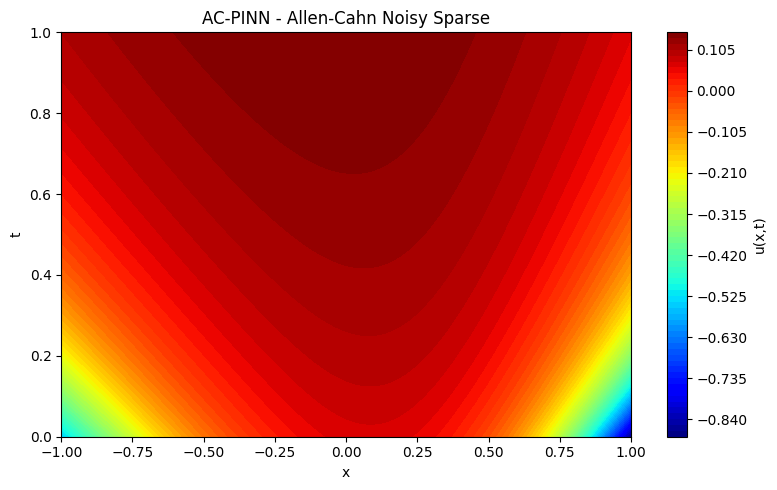

Saved: ../results/allen_cahn/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Allen-Cahn | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Allen-Cahn Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.147861   0.994449   0.034983   0.064818
  Vanilla (noisy)             0.316331   1.139461   0.069773   0.138671
  AC-PINN (clean)             0.817952   0.913094   0.234372   0.358566
  AC-PINN (noisy)             1.001455   1.093288   0.295534   0.439009


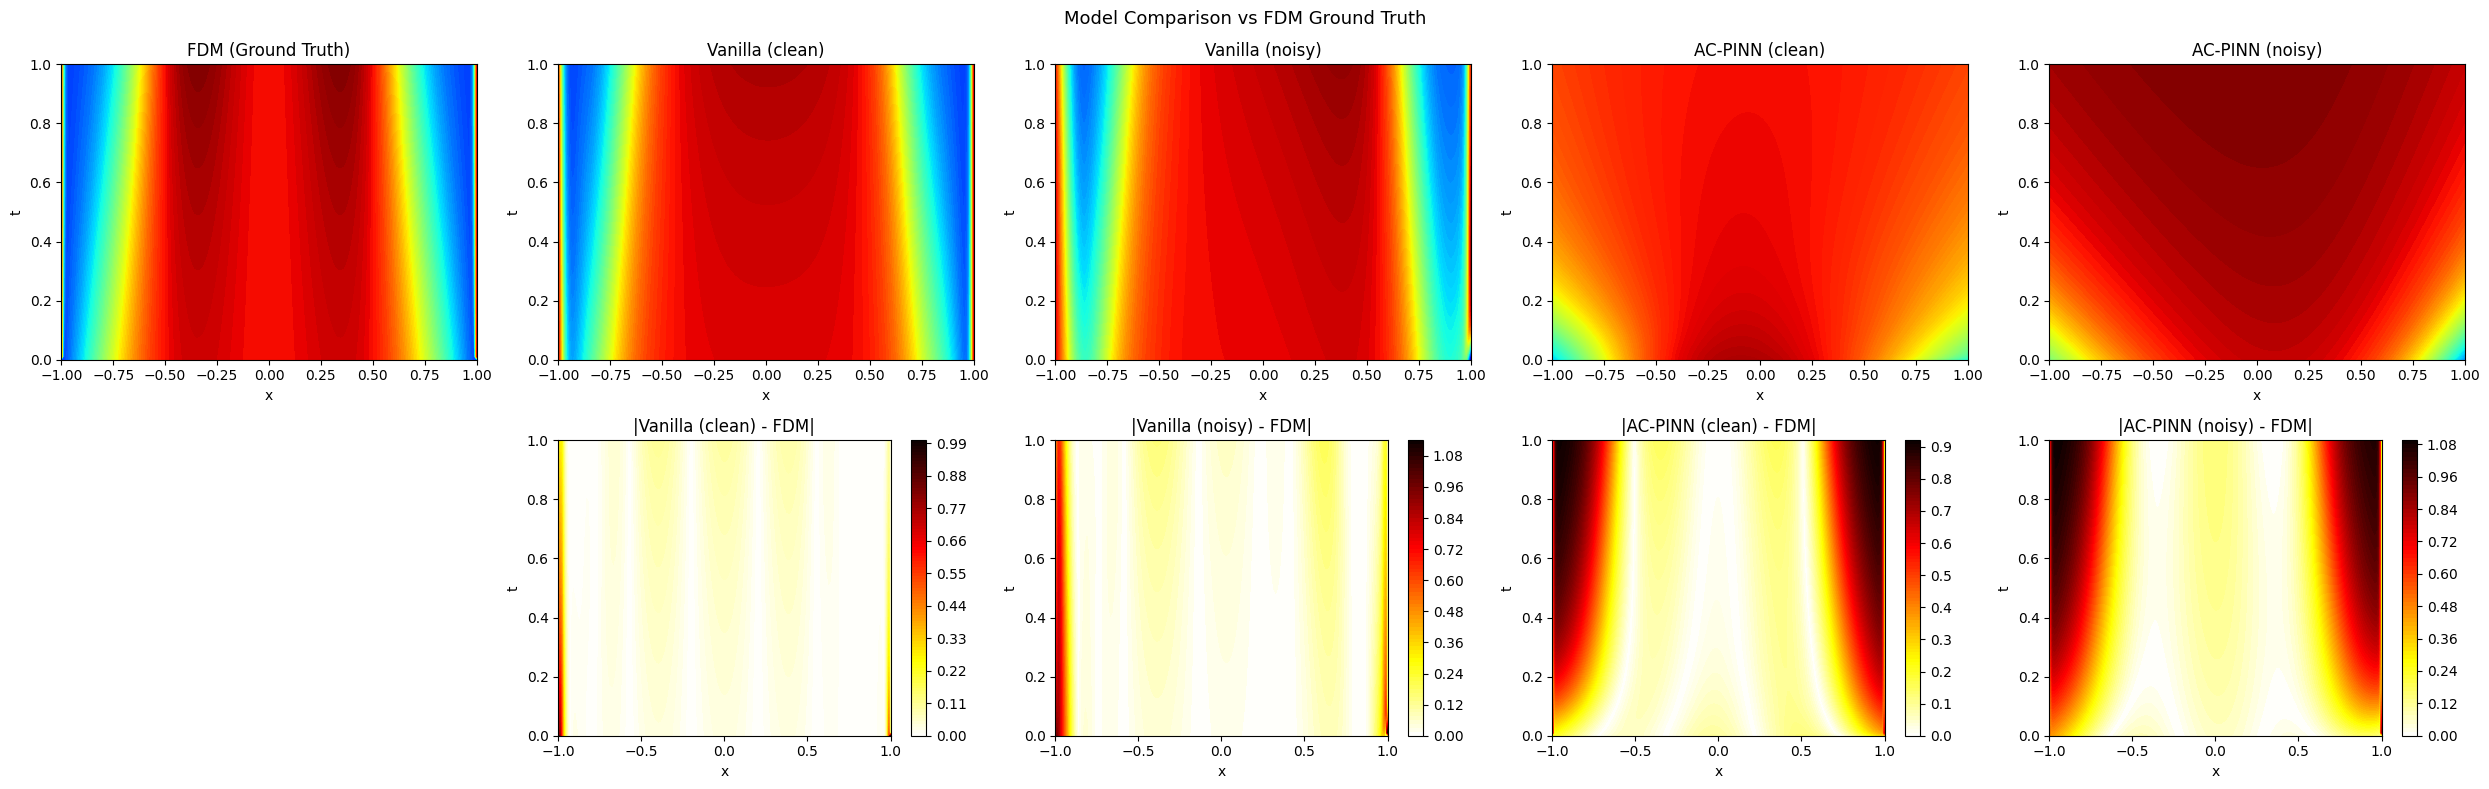

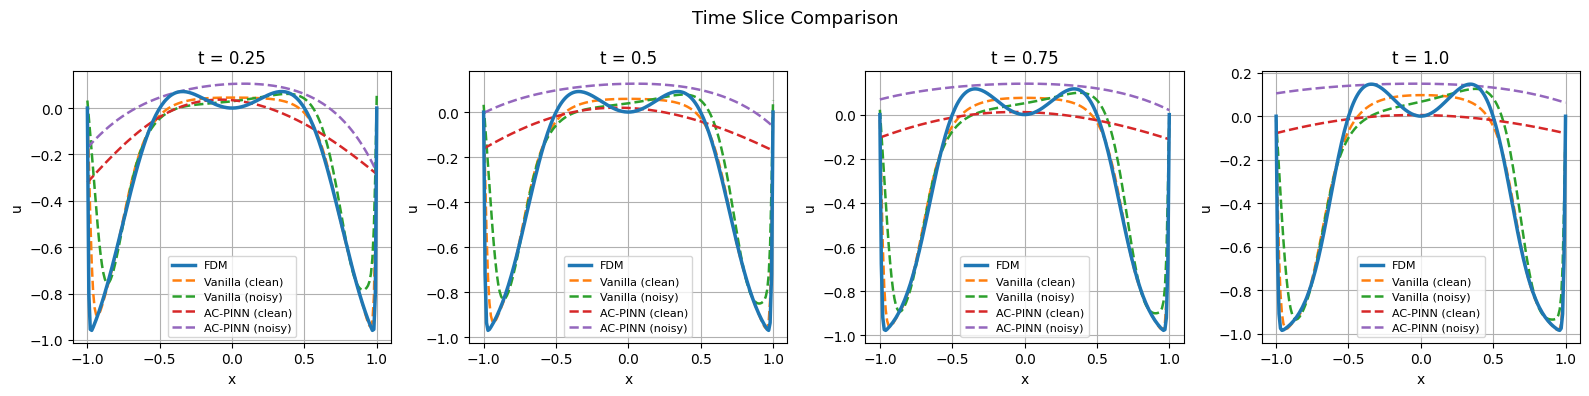

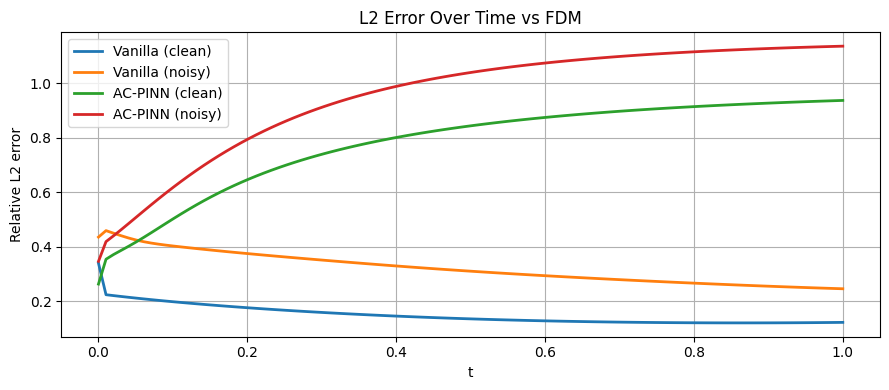

Saved: ../results/allen_cahn/benchmark_metrics.npy
Allen-Cahn experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Allen-Cahn experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=5000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, lambda_pde=10.0)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Allen-Cahn noise study complete.')


--- ε=0.05 ---
[Epoch     0/5000] Total: 0.985647 | IC: 0.177246 | BC: 0.253861 | PDE: 0.055454


[Epoch  2500/5000] Total: 0.126156 | IC: 0.112457 | BC: 0.008688 | PDE: 0.000501



Training complete in 79.17s
[Epoch     0/5000] Stage 1/4 | Total: 0.186324 | IC: 0.144285 | BC: 0.040440 | PDE: 0.000320 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.033925 | IC: 0.002147 | BC: 0.004996 | PDE: 0.000580 | lam=(7.86,3.21,1.78)



AC-PINN training complete in 85.44s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.299749   1.022814   0.067261   0.131402
  AC-PINN ε=0.05              0.989307   1.003484   0.288022   0.433684

--- ε=0.1 ---
[Epoch     0/5000] Total: 0.198867 | IC: 0.160319 | BC: 0.027754 | PDE: 0.001079


...


AC-PINN training complete in 85.55s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.728094   1.007865   0.185808   0.319176
  AC-PINN ε=0.1               0.940106   0.986515   0.269469   0.412115

--- ε=0.2 ---
[Epoch     0/5000] Total: 0.391204 | IC: 0.142702 | BC: 0.139496 | PDE: 0.010901


[Epoch  2500/5000] Total: 0.157667 | IC: 0.073656 | BC: 0.078769 | PDE: 0.000524



Training complete in 79.03s
[Epoch     0/5000] Stage 1/4 | Total: 0.305905 | IC: 0.134617 | BC: 0.157782 | PDE: 0.002701 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.415179 | IC: 0.022542 | BC: 0.053213 | PDE: 0.066437 | lam=(3.51,2.72,2.88)



AC-PINN training complete in 85.42s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.562935   1.030429   0.163410   0.246774
  AC-PINN ε=0.2               0.560013   1.059784   0.173553   0.245494
Saved: ../results/allen_cahn/noise_study_metrics.npy
Allen-Cahn noise study complete.
